# EDA — CIC-DDoS2019
**Mục tiêu:** Hiểu phân phối data, feature importance, và sự khác biệt giữa BENIGN vs DDoS traffic trước khi đưa vào model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

DATA_PATH = '../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
PROCESSED = '../data/processed'
print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Raw Data

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = df.columns.str.strip()

# Encode label
label_col = ' Label' if ' Label' in df.columns else 'Label'
df[label_col] = df[label_col].str.strip()
df['label'] = (df[label_col] != 'BENIGN').astype(int)

print(f'Shape       : {df.shape}')
print(f'Label col   : "{label_col}"')
print(f'\nLabel counts:')
print(df[label_col].value_counts())

Shape       : (225745, 86)
Label col   : "Label"

Label counts:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


## 2. Class Distribution

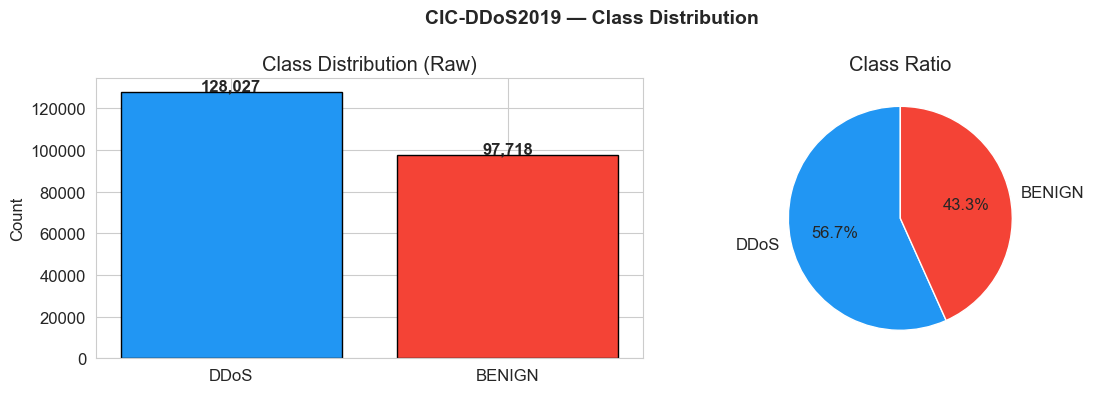

Saved → data/processed/eda_class_dist.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df[label_col].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Class Distribution (Raw)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Class Ratio')

plt.suptitle('CIC-DDoS2019 — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_class_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/processed/eda_class_dist.png')

## 3. Missing Values & Data Quality

Total features (numeric): 81
Features with missing/inf: 2


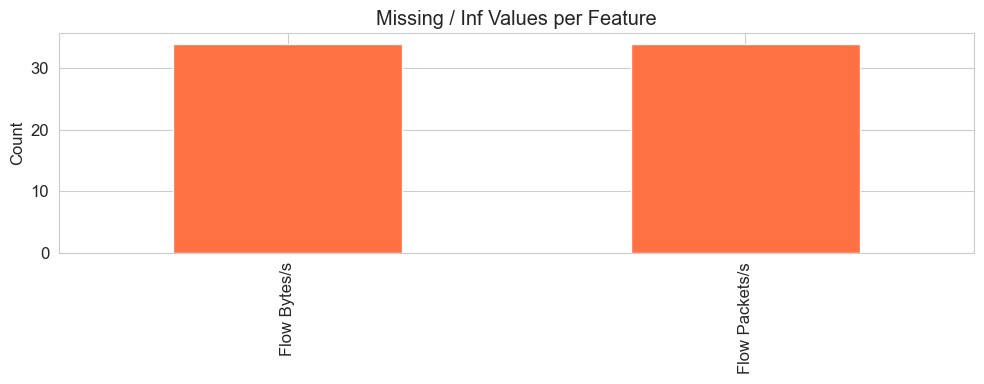

In [4]:
# Drop metadata cols trước
meta_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', label_col]
meta_cols = [c for c in meta_cols if c in df.columns]
df_feat = df.drop(columns=meta_cols)

# Numeric only
df_num = df_feat.select_dtypes(include=[np.number])

# Inf → NaN
df_num = df_num.replace([np.inf, -np.inf], np.nan)

missing = df_num.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f'Total features (numeric): {df_num.shape[1]}')
print(f'Features with missing/inf: {len(missing)}')

if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='bar', color='#FF7043')
    plt.title('Missing / Inf Values per Feature')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('../data/processed/eda_missing.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('✅ No missing values after inf replacement')

## 4. Feature Statistics — BENIGN vs DDoS

In [5]:
df_num['label'] = df['label'].values
df_num = df_num.dropna()

benign = df_num[df_num['label'] == 0].drop(columns=['label'])
ddos   = df_num[df_num['label'] == 1].drop(columns=['label'])

stats = pd.DataFrame({
    'BENIGN_mean' : benign.mean(),
    'DDoS_mean'   : ddos.mean(),
    'BENIGN_std'  : benign.std(),
    'DDoS_std'    : ddos.std(),
})
# Tính mean difference để tìm features phân biệt tốt nhất
stats['mean_diff'] = (stats['DDoS_mean'] - stats['BENIGN_mean']).abs()
stats = stats.sort_values('mean_diff', ascending=False)

print('Top 10 features phân biệt BENIGN vs DDoS (theo mean difference):')
display(stats.head(10)[['BENIGN_mean', 'DDoS_mean', 'mean_diff']].round(4))

Top 10 features phân biệt BENIGN vs DDoS (theo mean difference):


,BENIGN_mean,DDoS_mean,mean_diff
Bwd IAT Total,1.458874e+07,4.439220e+05,1.414481e+07
Bwd IAT Max,9.979164e+06,4.395152e+05,9.539649e+06
Fwd IAT Max,9.679387e+06,1.552717e+07,5.847787e+06
Flow IAT Max,1.041686e+07,1.583806e+07,5.421209e+06
Idle Max,9.899288e+06,1.515447e+07,5.255185e+06
Idle Mean,8.145784e+06,1.198550e+07,3.839713e+06
Packet Length Variance,8.676012e+05,4.257404e+06,3.389803e+06
Bwd IAT Std,3.434678e+06,2.186965e+05,3.215981e+06
Fwd IAT Total,1.393347e+07,1.651696e+07,2.583491e+06
Idle Min,6.367274e+06,8.816552e+06,2.449279e+06


## 5. Top Features Distribution Plot

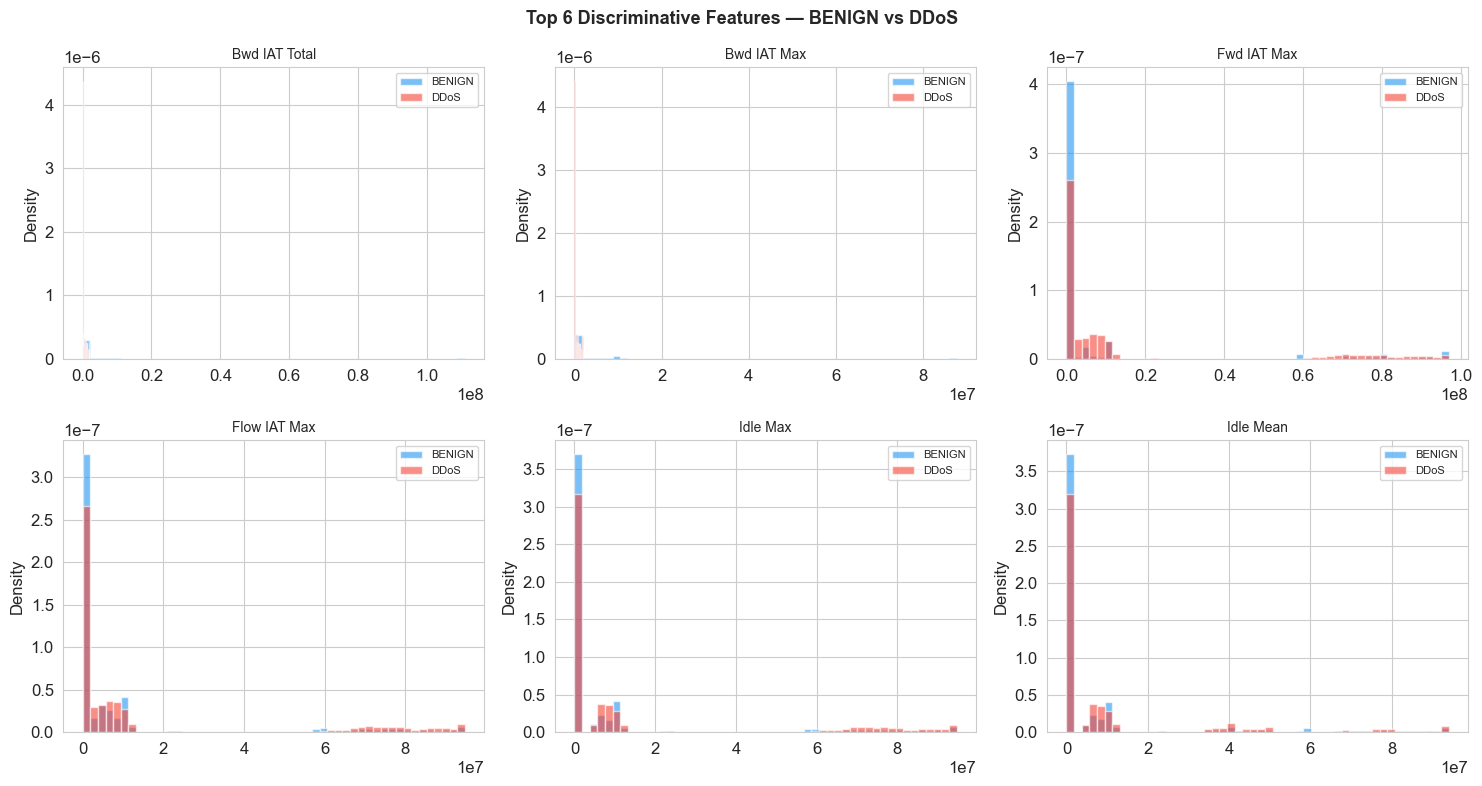

Saved → data/processed/eda_top_features.png


In [6]:
top_features = stats.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    # Clip outliers để plot đẹp hơn
    p1, p99 = df_num[feat].quantile([0.01, 0.99])
    data_b = benign[feat].clip(p1, p99)
    data_d = ddos[feat].clip(p1, p99)

    ax.hist(data_b, bins=50, alpha=0.6, color='#2196F3', label='BENIGN', density=True)
    ax.hist(data_d, bins=50, alpha=0.6, color='#F44336', label='DDoS',   density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.suptitle('Top 6 Discriminative Features — BENIGN vs DDoS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/processed/eda_top_features.png')

## 6. Correlation Heatmap (Top 20 Features)

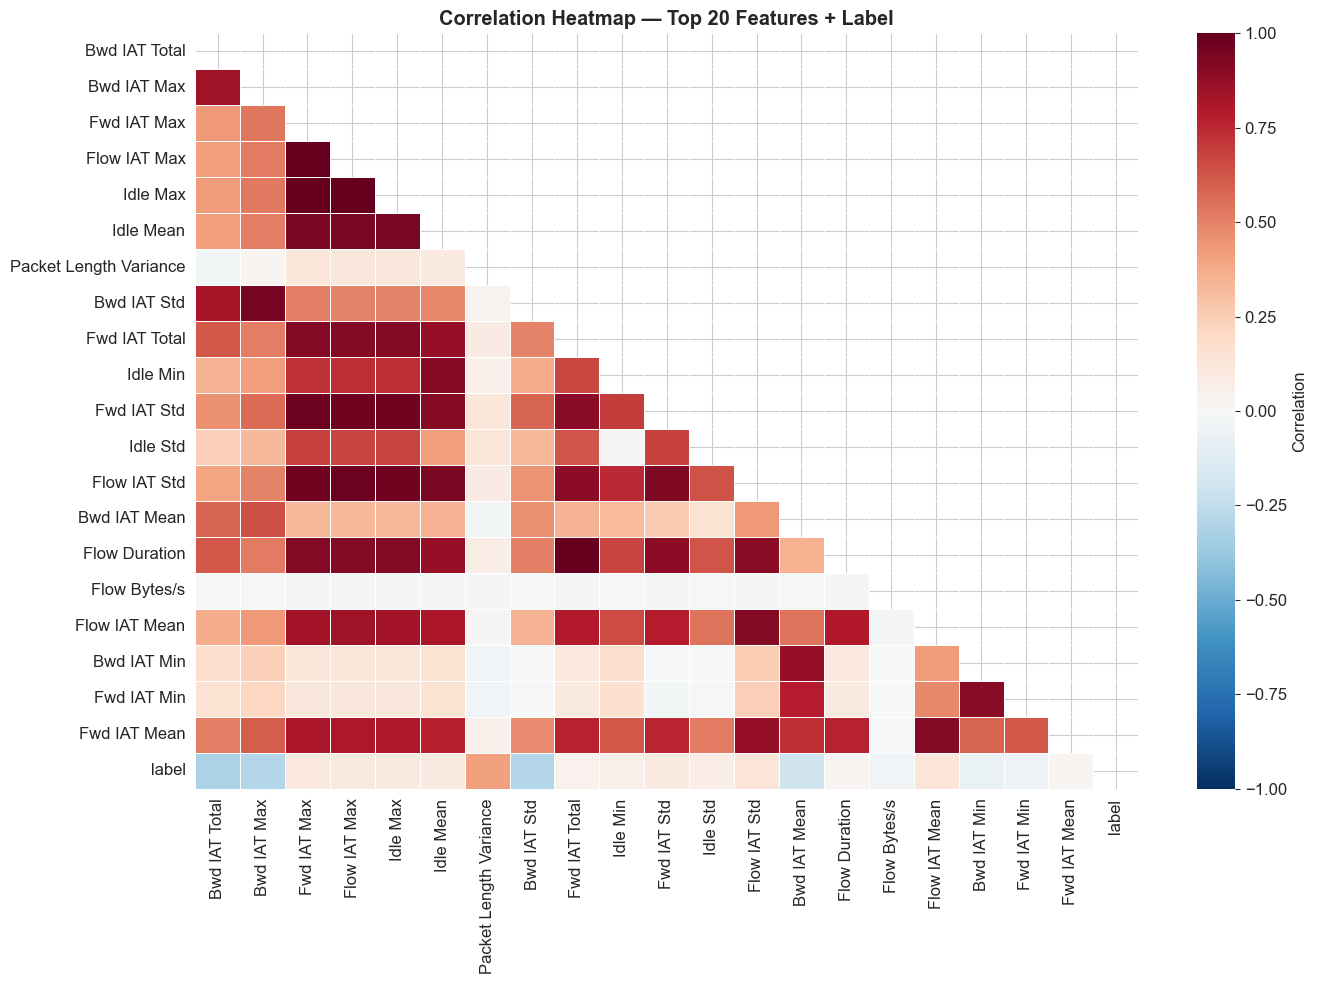

Saved → data/processed/eda_correlation.png


In [7]:
top20 = stats.head(20).index.tolist()
corr  = df_num[top20 + ['label']].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap — Top 20 Features + Label', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/processed/eda_correlation.png')

## 7. Feature Importance (sau khi preprocess)

Training Random Forest for feature importance (100 trees) ...


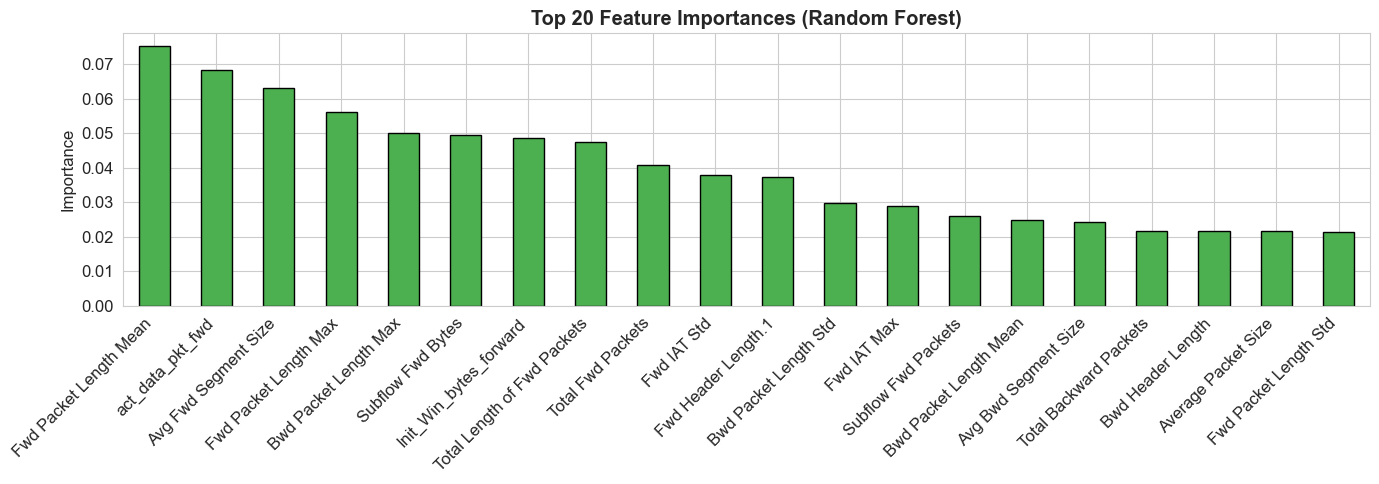


Top 10 most important features:
Fwd Packet Length Mean         0.075210
act_data_pkt_fwd               0.068321
Avg Fwd Segment Size           0.063252
Fwd Packet Length Max          0.056269
Bwd Packet Length Max          0.049971
Subflow Fwd Bytes              0.049418
Init_Win_bytes_forward         0.048696
Total Length of Fwd Packets    0.047550
Total Fwd Packets              0.040718
Fwd IAT Std                    0.037785

Saved → data/processed/eda_feature_importance.png


In [8]:
from sklearn.ensemble import RandomForestClassifier

X_train = np.load(f'{PROCESSED}/X_train.npy')
y_train = np.load(f'{PROCESSED}/y_train.npy')

with open(f'{PROCESSED}/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Train RF nhanh để lấy feature importance
print('Training Random Forest for feature importance (100 trees) ...')
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(14, 5))
importances.head(20).plot(kind='bar', color='#4CAF50', edgecolor='black')
plt.title('Top 20 Feature Importances (Random Forest)', fontweight='bold')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/eda_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 most important features:')
print(importances.head(10).to_string())
print('\nSaved → data/processed/eda_feature_importance.png')

## 8. Processed Data Summary

In [9]:
X_val  = np.load(f'{PROCESSED}/X_val.npy')
X_test = np.load(f'{PROCESSED}/X_test.npy')
y_val  = np.load(f'{PROCESSED}/y_val.npy')
y_test = np.load(f'{PROCESSED}/y_test.npy')

print('=' * 45)
print('  Processed Dataset Summary')
print('=' * 45)
print(f'  Features     : {X_train.shape[1]}')
print(f'  Train        : {len(X_train):,} samples')
print(f'    BENIGN     : {(y_train==0).sum():,}')
print(f'    DDoS       : {(y_train==1).sum():,}')
print(f'  Val          : {len(X_val):,} samples')
print(f'  Test         : {len(X_test):,} samples')
print(f'  Feature range (train):')
print(f'    min = {X_train.min():.3f}')
print(f'    max = {X_train.max():.3f}')
print(f'    mean= {X_train.mean():.3f}')
print('=' * 45)
print('✅ EDA Complete — tất cả plots đã save vào data/processed/')

  Processed Dataset Summary
  Features     : 80
  Train        : 136,760 samples
    BENIGN     : 68,380
    DDoS       : 68,380
  Val          : 29,306 samples
  Test         : 29,306 samples
  Feature range (train):
    min = -16.392
    max = 164.686
    mean= -0.000
✅ EDA Complete — tất cả plots đã save vào data/processed/
